# 모듈 불러오기 & 기본 설정

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

In [5]:
!pip install koreanize_matplotlib
import koreanize_matplotlib

# 데이터 로드

In [6]:
# 데이터 로드
performance = pd.read_excel('경기전반_실적.xlsx')
outlook = pd.read_excel('경기전반_전망.xlsx')

# 데이터 파악 & 데이터 정제

In [7]:
# 데이터 파악
# print(performance)
# print(outlook)

# print(performance.columns)
# print(performance.info())
# print(performance['2025.03'])


# 이름 변경
performance = performance.rename(columns={
    '구분별(1)': 'dis01',
    '구분별(2)': 'dis02',
    '구분별(3)': 'dis03',
    '2025.01.5': '01_SBHI',
    '2025.02.5': '02_SBHI',
    '2025.03.5': '03_SBHI',
    '2025.04.5': '04_SBHI',
    '2025.05.5': '05_SBHI'
})

outlook = outlook.rename(columns={
    '구분별(1)': 'dis01',
    '구분별(2)': 'dis02',
    '구분별(3)': 'dis03',
    '2025.01.5': '01_SBHI',
    '2025.02.5': '02_SBHI',
    '2025.03.5': '03_SBHI',
    '2025.04.5': '04_SBHI',
    '2025.05.5': '05_SBHI'
})
# print(performance.columns)
print(outlook.columns)

# 결측치, 이상치, 극단치 확인
# print(performance.isna().sum())
# print(performance.describe())
print(outlook.isna().sum())
print(outlook.describe())

Index(['dis01', 'dis02', 'dis03', '2025.01', '2025.01.1', '2025.01.2',
       '2025.01.3', '2025.01.4', '01_SBHI', '2025.02', '2025.02.1',
       '2025.02.2', '2025.02.3', '2025.02.4', '02_SBHI', '2025.03',
       '2025.03.1', '2025.03.2', '2025.03.3', '2025.03.4', '03_SBHI',
       '2025.04', '2025.04.1', '2025.04.2', '2025.04.3', '2025.04.4',
       '04_SBHI', '2025.05', '2025.05.1', '2025.05.2', '2025.05.3',
       '2025.05.4', '05_SBHI', '2025.06', '2025.06.1', '2025.06.2',
       '2025.06.3', '2025.06.4', '2025.06.5'],
      dtype='object')
dis01        0
dis02        0
dis03        0
2025.01      0
2025.01.1    0
2025.01.2    0
2025.01.3    0
2025.01.4    0
01_SBHI      0
2025.02      0
2025.02.1    0
2025.02.2    0
2025.02.3    0
2025.02.4    0
02_SBHI      0
2025.03      0
2025.03.1    0
2025.03.2    0
2025.03.3    0
2025.03.4    0
03_SBHI      0
2025.04      0
2025.04.1    0
2025.04.2    0
2025.04.3    0
2025.04.4    0
04_SBHI      0
2025.05      0
2025.05.1    0
2025.05.2    

# 데이터 분석 01 : 구조별

In [8]:
# 구조별 데이터프레임 생성
performance_scale = performance.query('`dis02` == "구조별"') \
    [['dis01', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI']]
print(performance_scale)

    dis01  dis03 01_SBHI 02_SBHI 03_SBHI 04_SBHI 05_SBHI
5   중소제조업    경공업    68.1    68.6    72.1      74    76.1
47  중소제조업  중화학공업      70    73.6    76.7    77.5    77.9


# 01-01 기업의 크기별
- 전반적으로 중기업이 소기업에 비해 SBHI 지수가 8.6정도 높음.
- 비제조업 분야는 7.7 정도의 차이가 남.
- 제조업 분야는 11 정도의 차이가 남.

    dis01 dis03 mean_sbhi
0     전산업   소기업     64.64
1     전산업   중기업     73.22
2  중소비제조업   소기업     62.74
3  중소비제조업   중기업     70.56
4   중소제조업   소기업      68.8
5   중소제조업   중기업     79.84


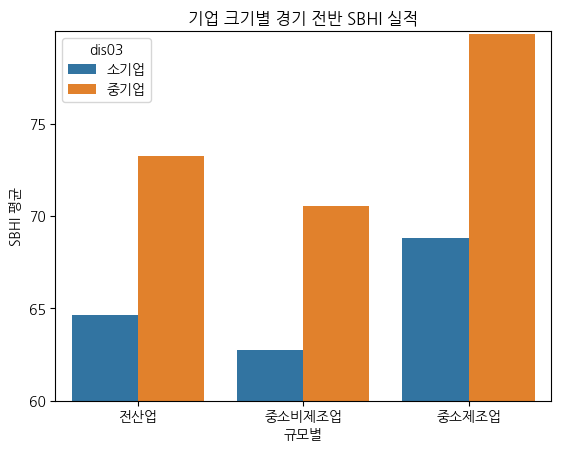

    dis01 dis03 mean_sbhi
0     전산업   소기업     67.64
1     전산업   중기업     77.12
2  중소비제조업   소기업      64.7
3  중소비제조업   중기업     74.38
4   중소제조업   소기업      74.0
5   중소제조업   중기업     83.82


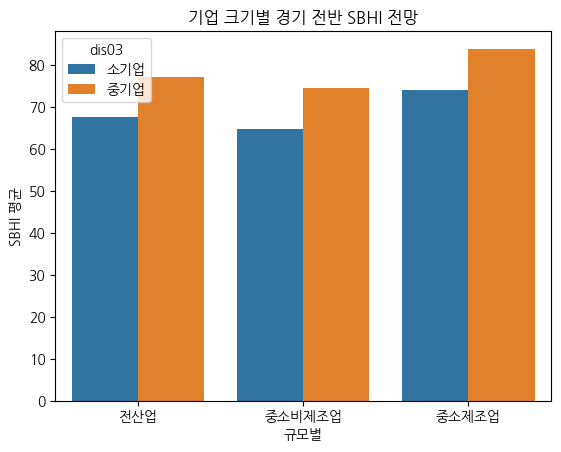

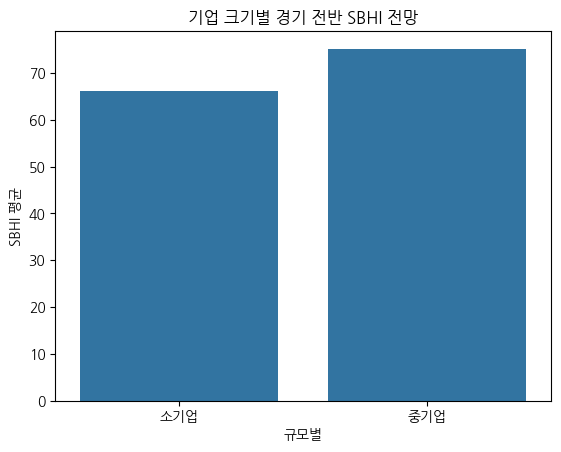

In [9]:
# 규모별 데이터프레임 생성
performance_type = performance.query('`dis02` == "규모별"') \
    [['dis01', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI']]
# print(performance_type)

### 01-1 인사이트
dis01_dis02 = performance_type.assign(total_sbhi = (performance_type['01_SBHI'] + performance_type['02_SBHI'] + performance_type['03_SBHI'] + performance_type['04_SBHI'] + performance_type['05_SBHI'])/5) \
            .groupby(['dis01', 'dis03'], as_index=False) \
            .agg(mean_sbhi = ('total_sbhi', 'mean'))
print(dis01_dis02)

a = dis01_dis02.query('dis01 == "전산업"')

sns.barplot(data=dis01_dis02, x='dis01', y='mean_sbhi', hue='dis03')
plt.title('기업 크기별 경기 전반 SBHI 실적')
plt.xlabel('규모별')
plt.ylabel('SBHI 평균')
plt.ylim(60, 80)
plt.yticks(np.arange(60, 80, 5))
plt.show()



# 규모별 데이터프레임 생성
outlook_type = outlook.query('`dis02` == "규모별"') \
    [['dis01', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI']]
# print(outlook_type)

### 01-1 인사이트
dis01_dis02_out = outlook_type.assign(total_sbhi = (outlook_type['01_SBHI'] + outlook_type['02_SBHI'] + outlook_type['03_SBHI'] + outlook_type['04_SBHI'] + outlook_type['05_SBHI'])/5) \
            .groupby(['dis01', 'dis03'], as_index=False) \
            .agg(mean_sbhi = ('total_sbhi', 'mean'))
print(dis01_dis02_out)

sns.barplot(data=dis01_dis02_out, x='dis01', y='mean_sbhi', hue='dis03')
plt.title('기업 크기별 경기 전반 SBHI 전망')
plt.xlabel('규모별')
plt.ylabel('SBHI 평균')
plt.show()

a = pd.concat([performance_type, outlook_type])

b = a.query('dis01 == "전산업"') \
.assign(total_sbhi = (a['01_SBHI'] + a['02_SBHI'] + a['03_SBHI'] + a['04_SBHI'] + a['05_SBHI'])/5) \
.groupby('dis03', as_index=False) \
.agg(mean_sbhi = ('total_sbhi', 'mean'))

sns.barplot(data=b, x='dis03', y='mean_sbhi')
plt.title('기업 크기별 경기 전반 SBHI 전망')
plt.xlabel('규모별')
plt.ylabel('SBHI 평균')
plt.show()

# 01-02 업종별 실적
- 현재 실적이 가장 높은 업종들은 운송 장비 & 식음료, 정보서비스업에 해당됨.
- 그 중에서 운송과 관련된 업이 SBHI가 가장 높음.
- 음료 -> 정보서비스업 -> 식료품 순서대로 SBHI가 높음.


                  dis03 mean_sbhi
8               기타 운송장비     88.84
28           자동차 및 트레일러     87.84
23                   음료     85.72
32  출판,영상,방송통신 및 정보서비스업      84.4
20                  식료품     84.02
25         의료용 물질 및 의약품     83.96


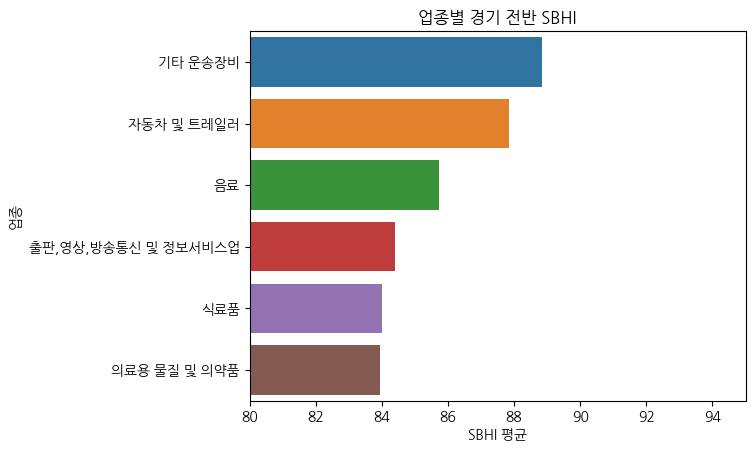

In [10]:
# 업종별 실적 데이터프레임 생성
performance_industry = performance.query('`dis02` == "업종별"') \
    [['dis01', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI']]
# print(performance_industry)

# 2025년 1월 ~ 2025년 5월 SBHI 지수가 높은 5개의 업은 뭐가 있을까?
df03 = performance_industry.assign(total_sbhi = (performance_industry['01_SBHI'] + performance_industry['02_SBHI'] + performance_industry['03_SBHI'] + performance_industry['04_SBHI'] + performance_industry['05_SBHI'])/5) \
            .groupby('dis03', as_index=False) \
            .agg(mean_sbhi = ('total_sbhi', 'mean')) \
            .sort_values('mean_sbhi', ascending=False) \
            .head(6)
print(df03)

sns.barplot(data=df03, x='mean_sbhi', y='dis03', hue='dis03')
plt.title('업종별 경기 전반 SBHI')
plt.xlabel('SBHI 평균')
plt.ylabel('업종')
plt.xlim(80, 95)
plt.show()

# 01-03 업종별 전망
- 식료품의 SPHI는 0.4 차이로 거의 같지만, 5위에서 8위로 떨어짐.
- 6위였던 의료용 물질 및 의약품은 6,0정도 높게 평가되며 6위에서 2위로 상승
- 교육서비스업은 1.4 감소하고, 7위에서 13위로 떨어짐
- 전자 제품들은 실적이 식료품보다 낮지만, 전망은 식료품보다 높게 평가됨.
약 6~7 정도 높게 평가됨.

                  dis03 mean_sbhi
8               기타 운송장비     91.22
25         의료용 물질 및 의약품      89.9
28           자동차 및 트레일러      88.3
23                   음료     86.82
32  출판,영상,방송통신 및 정보서비스업      86.6


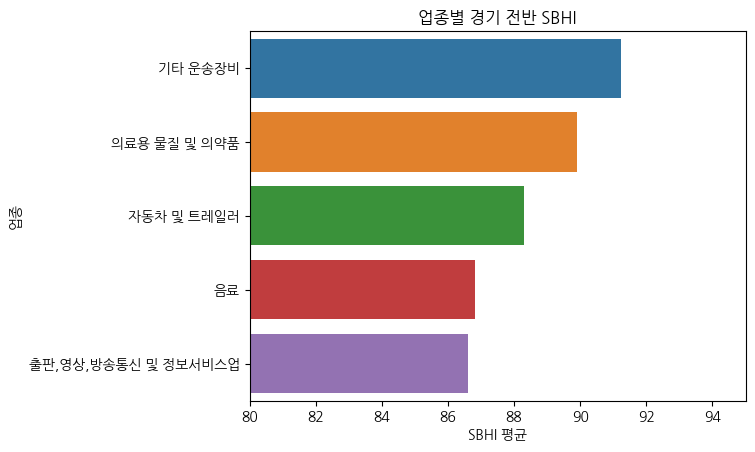

In [11]:
# 업종별 실적 데이터프레임 생성
outlook_industry = outlook.query('`dis02` == "업종별"') \
    [['dis01', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI']]
# print(outlook_industry)

# 2025년 1월 ~ 2025년 5월 SBHI 지수가 높은 5개의 업은 뭐가 있을까?
df04 = outlook_industry.assign(total_sbhi = (outlook_industry['01_SBHI'] + outlook_industry['02_SBHI'] + outlook_industry['03_SBHI'] + outlook_industry['04_SBHI'] + outlook_industry['05_SBHI'])/5) \
            .groupby('dis03', as_index=False) \
            .agg(mean_sbhi = ('total_sbhi', 'mean')) \
            .sort_values('mean_sbhi', ascending=False) \
            .head(5)
print(df04)

sns.barplot(data=df04, x='mean_sbhi', y='dis03', hue='dis03')
plt.title('업종별 경기 전반 SBHI')
plt.xlabel('SBHI 평균')
plt.ylabel('업종')
plt.xlim(80, 95)
plt.show()

# 01-04 실적 대비 전망의 SBHI가 가장 많이 상승한 업종
- 섬유 제품이 실적 대비 전망이 11.82 상승, 가죽&가방&신발 업종도 7.54 상승 -> 의류 관련 브랜드가 많이 등장한 것의 근거가 될 듯함.
- 고무 제품 및 플라스틱이 실적 대비 전망이 7.4 상승 -> 환경에 유해하지만, 이를 대체할 물품이 아직 발견되지 않았다 판단

            dis03 sbhi_outlook_performance
17           섬유제품                    11.82
15  산업용기계 및 장비수리업                    11.04
34    화학물질 및 화학제품                      8.6
6          금속가공제품                     8.22
2     가죽, 가방 및 신발                     7.54


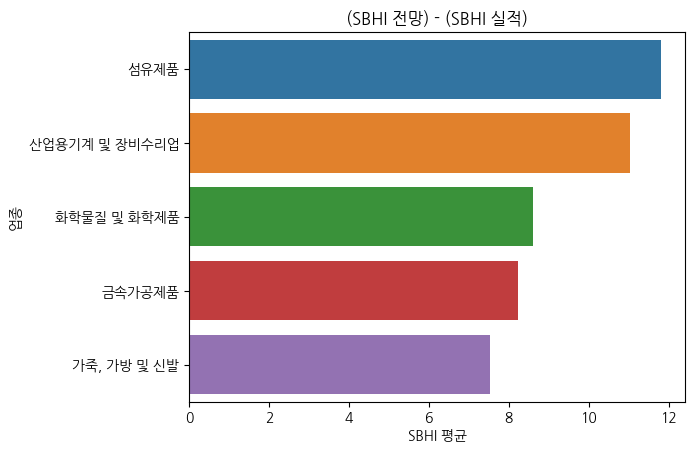

In [12]:
# total 파생 변수 생성
total_performance = performance_industry.assign(performance_total_sbhi = (performance_industry['01_SBHI'] + performance_industry['02_SBHI'] + performance_industry['03_SBHI'] + performance_industry['04_SBHI'] + performance_industry['05_SBHI'])/5)
total_outlook = outlook_industry.assign(outlook_total_sbhi = (outlook_industry['01_SBHI'] + outlook_industry['02_SBHI'] + outlook_industry['03_SBHI'] + outlook_industry['04_SBHI'] + outlook_industry['05_SBHI'])/5)

# 월별 SBHI 제거
total_performance_drop = total_performance.drop(columns=['dis01', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI'])
total_outlook_drop = total_outlook.drop(columns=['dis01', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI'])

# 확인
# print(total_performance_drop.head())
# print(total_outlook_drop.head())

# 두 데이터프레임 결합
performance_outlook = pd.merge(total_performance_drop, total_outlook_drop, how='left', on='dis03')

# (전망 - 실적) 파생 변수 생성
performance_outlook = performance_outlook.assign(sbhi_outlook_performance = performance_outlook['outlook_total_sbhi'] - performance_outlook['performance_total_sbhi'])

# 차이가 가장 많이 나는 업종 출력
performance_outlook_sort = performance_outlook.drop(columns=['performance_total_sbhi', 'outlook_total_sbhi']) \
  .sort_values('sbhi_outlook_performance', ascending=False) \
  .head(5)
print(performance_outlook_sort)

# 그래프로 시각화
sns.barplot(data=performance_outlook_sort, x='sbhi_outlook_performance', y='dis03', hue='dis03')
plt.title("(SBHI 전망) - (SBHI 실적)")
plt.xlabel('SBHI 평균')
plt.ylabel('업종')
plt.show()

# 생산, 내수판매, 수출 데이터로드

In [13]:
production_performance = pd.read_excel('생산실적_제조.xlsx')
production_outlook = pd.read_excel('생산전망_제조.xlsx')

In [14]:
# 생산 데이터 파악 & 정제
# production_performance.info()
# print(production_performance.describe())

# production_outlook.info()
# production_outlook.describe()

production_performance = production_performance.rename(columns={
    '구분별(1)': 'dis01',
    '구분별(2)': 'dis02',
    '구분별(3)': 'dis03',
    '2025.01.5': '01_SBHI',
    '2025.02.5': '02_SBHI',
    '2025.03.5': '03_SBHI',
    '2025.04.5': '04_SBHI',
    '2025.05.5': '05_SBHI',
    '2025.06.5': '06_SBHI'
})

production_outlook = production_outlook.rename(columns={
    '구분별(1)': 'dis01',
    '구분별(2)': 'dis02',
    '구분별(3)': 'dis03',
    '2025.01.5': '01_SBHI',
    '2025.02.5': '02_SBHI',
    '2025.03.5': '03_SBHI',
    '2025.04.5': '04_SBHI',
    '2025.05.5': '05_SBHI',
    '2025.06.5': '06_SBHI',
    '2025.07.5': '07_SBHI'
})

# production_performance.columns
# production_outlook.columns

# 문자열 -> 숫자로 형 변환하기
for col in ['01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI']:
    production_performance[col] = pd.to_numeric(production_performance[col], errors='coerce')

for col in ['01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI', '07_SBHI']:
    production_outlook[col] = pd.to_numeric(production_outlook[col], errors='coerce')

# 필요한 열 추출, 파생 변수 생성
production_performance_SBHI = production_performance[['dis01','dis02', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI']] \
.assign(total_sbhi_pref = (production_performance['01_SBHI'] + production_performance['02_SBHI'] + production_performance['03_SBHI'] + production_performance['04_SBHI'] + production_performance['05_SBHI'] + production_performance['06_SBHI'])/6)


production_outlook_SBHI = production_outlook[['dis01','dis02', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI', '07_SBHI']] \
.assign(total_sbhi_outlook = (production_outlook['01_SBHI'] + production_outlook['02_SBHI'] + production_outlook['03_SBHI'] + production_outlook['04_SBHI'] + production_outlook['05_SBHI'] + production_outlook['06_SBHI'] + production_outlook['07_SBHI'])/7)

# 전반적인 생산 SBHI 수치 파악
- 소기업 실적 SBHI : 73.1
- 중기업 실적 SBHI : 82.4

- 소기업 전망 SBHI : 77.3
- 중기업 전망 SBHI : 86.1

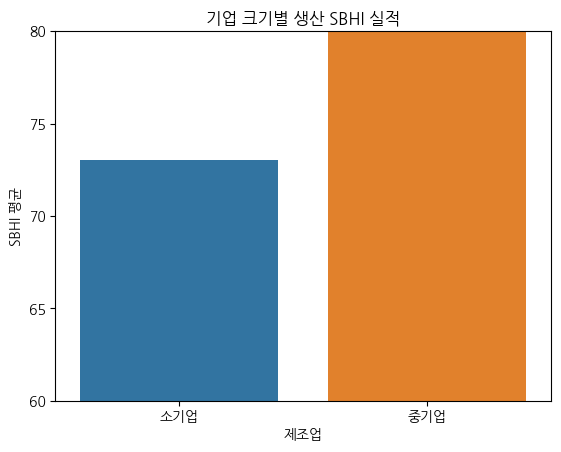

  dis03  total_sbhi_pref
4   소기업        73.050000
5   중기업        82.383333


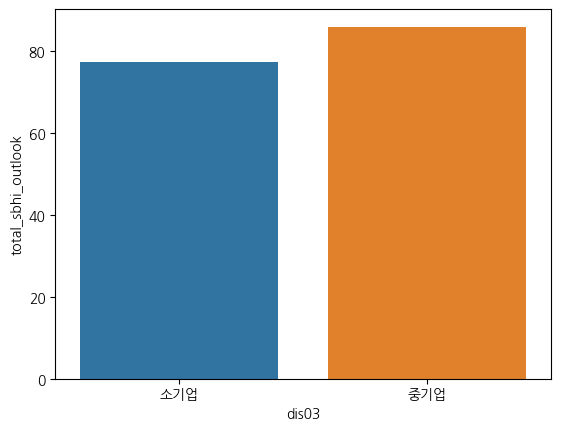

  dis03  total_sbhi_outlook
4   소기업           77.314286
5   중기업           86.057143


,dis01,dis03,01_SBHI,02_SBHI,03_SBHI,04_SBHI,05_SBHI
24,전산업,소기업,57.8,59.9,67.8,68.6,69.1
25,중소제조업,소기업,63.9,65.4,70.6,70.7,73.4
26,중소비제조업,소기업,54.9,57.4,66.6,67.7,67.1
44,전산업,중기업,71.2,71.1,73.8,75.8,74.2
45,중소제조업,중기업,75.4,79.2,80.3,82.7,81.6
46,중소비제조업,중기업,69.5,67.8,71.2,73,71.3
2,전산업,소기업,62.9,62.5,69.7,72.3,70.8
3,전산업,중기업,73.4,72.6,79.8,79.2,80.6
10,중소제조업,소기업,69.3,68.6,77,79,76.1
11,중소제조업,중기업,79.3,82.5,84.8,86.5,86


In [15]:
# 전반적인 SBHI 수치 파악 -> 소기업 & 중기업의 SBHI 실적 & 전망 확인

all_production_perf = production_performance_SBHI.query('dis02 == "규모별"') \
  [['dis03', 'total_sbhi_pref']]
sns.barplot(data=all_production_perf, x='dis03', y='total_sbhi_pref', hue='dis03')
plt.title('기업 크기별 생산 SBHI 실적')
plt.xlabel('제조업')
plt.ylabel('SBHI 평균')
plt.ylim(60, 80)
plt.yticks(np.arange(60, 81, 5))
plt.show()
print(all_production_perf)


all_production_outlook = production_outlook_SBHI.query('dis02 == "규모별"') \
  [['dis03', 'total_sbhi_outlook']]
sns.barplot(data=all_production_outlook, x='dis03', y='total_sbhi_outlook', hue='dis03')
plt.show()
print(all_production_outlook)

a

# 실적 / 전망의 SBHI 지수 가장 높은 업종 찾기

### 실적
- 기타 운송장비 실적 SBHI : 90.1
- 의료용 물질 및 의약품 실적 SBHI : 89.733333
- 식료품 실적 SBHI : 88.150000
- 자동차 및 트레일러 실적 SBHI : 87.433333
- 음료 실적 SBHI : 86.816667

### 전망
- 의료용 물질 및 의약품 전망 SBHI : 95.985714
- 자동차 및 트레일러 전망 SBHI : 91.871429
- 기타 운송장비 전망 SBHI : 89.328571
- 음료 전망 SBHI : 88.714286
- 식료품 전망 SBHI : 87.485714


           dis03  total_sbhi_pref
25       기타 운송장비        90.933333
15  의료용 물질 및 의약품        89.733333
6            식료품        88.150000
24    자동차 및 트레일러        87.433333
7             음료        86.816667


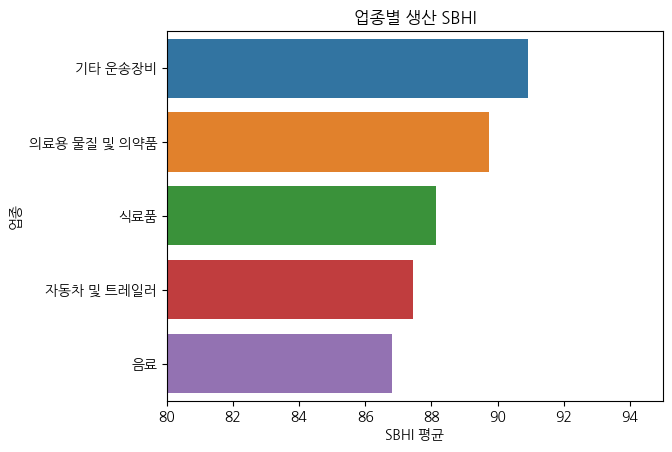

           dis03  total_sbhi_outlook
15  의료용 물질 및 의약품           95.985714
24    자동차 및 트레일러           91.871429
25       기타 운송장비           89.328571
7             음료           88.714286
6            식료품           87.485714


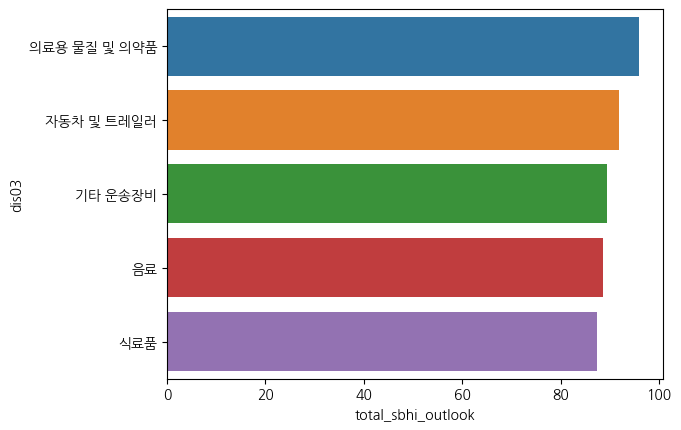

In [16]:
# 실적 / 전망의 SBHI 지수 가장 높은 업종 찾기
top5_production_pref = production_performance_SBHI.query('dis02 == "업종별"') \
  [['dis03', 'total_sbhi_pref']] \
  .sort_values('total_sbhi_pref', ascending=False) \
  .head(5)

top5_production_outlook = production_outlook_SBHI.query('dis02 == "업종별"') \
  [['dis03', 'total_sbhi_outlook']] \
  .sort_values('total_sbhi_outlook', ascending=False) \
  .head(5)


# 시각화 하기
print(top5_production_pref)
sns.barplot(data=top5_production_pref, x='total_sbhi_pref', y='dis03', hue='dis03')
plt.title("업종별 생산 SBHI")
plt.xlabel("SBHI 평균")
plt.ylabel("업종")
plt.xlim(80, 95)
plt.show()

print(top5_production_outlook)
sns.barplot(data=top5_production_outlook, x='total_sbhi_outlook', y='dis03', hue='dis03')
plt.show()

# 실적 대비 전망이 가장 높은 업종 확인
- 섬유제품
  - 실적 : 61.550000
  - 전망 : 72.728571
  - 차이 : 11.178571

- 고무제품 및 플라스틱
  - 실적 : 72.033333
  - 전망 : 79.300000
  - 차이 : 7.266667

- 가죽, 가방 및 신발
  - 실적 : 76.550000
  - 전망 : 83.728571
  - 차이 : 7.178571

- 화학물질 및 화학제품
  - 실적 : 76.316667
  - 전망 : 82.585714
  - 차이 : 6.269048

- 의료용 물질 및 의약품
  - 실적 : 89.733333
  - 전망 : 95.985714
  - 차이 : 6.252381

           dis03  total_sbhi_pref  total_sbhi_outlook  outlook_pref
8           섬유제품        61.550000           72.728571     11.178571
16   고무제품 및 플라스틱        72.033333           79.300000      7.266667
10   가죽, 가방 및 신발        76.550000           83.728571      7.178571
14   화학물질 및 화학제품        76.316667           82.585714      6.269048
15  의료용 물질 및 의약품        89.733333           95.985714      6.252381


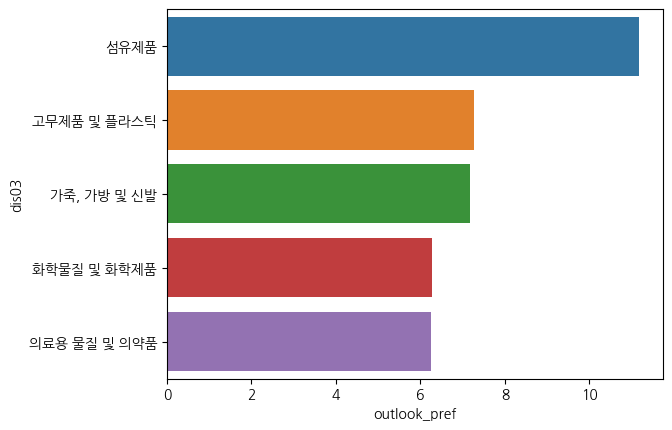

In [17]:
top5_production_pref_outlook = pd.merge(production_performance_SBHI[['dis03', 'total_sbhi_pref']], production_outlook_SBHI[['dis03', 'total_sbhi_outlook']], how='left', on='dis03')

new = top5_production_pref_outlook.assign(outlook_pref = top5_production_pref_outlook['total_sbhi_outlook'] - top5_production_pref_outlook['total_sbhi_pref']) \
.sort_values('outlook_pref', ascending=False) \
.head(5)

print(new)
sns.barplot(data=new, x='outlook_pref', y='dis03', hue='dis03')
plt.show()

# 내수 판매 실적 & 전망 확인

In [18]:
Domestic_sales_performance = pd.read_excel('내수판매_실적.xlsx')
Domestic_sales_outlook = pd.read_excel('내수판매_전망.xlsx')

In [19]:
Domestic_sales_performance = Domestic_sales_performance.rename(columns={
    '구분별(1)': 'dis01',
    '구분별(2)': 'dis02',
    '구분별(3)': 'dis03',
    '2025.01.5': '01_SBHI',
    '2025.02.5': '02_SBHI',
    '2025.03.5': '03_SBHI',
    '2025.04.5': '04_SBHI',
    '2025.05.5': '05_SBHI',
    '2025.06.5': '06_SBHI'
})

Domestic_sales_outlook = Domestic_sales_outlook.rename(columns={
    '구분별(1)': 'dis01',
    '구분별(2)': 'dis02',
    '구분별(3)': 'dis03',
    '2025.01.5': '01_SBHI',
    '2025.02.5': '02_SBHI',
    '2025.03.5': '03_SBHI',
    '2025.04.5': '04_SBHI',
    '2025.05.5': '05_SBHI',
    '2025.06.5': '06_SBHI',
    '2025.07.5': '07_SBHI'
})

# production_performance.columns
# production_outlook.columns

# 문자열 -> 숫자로 형 변환하기
for col in ['01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI']:
    Domestic_sales_performance[col] = pd.to_numeric(Domestic_sales_performance[col], errors='coerce')

for col in ['01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI', '07_SBHI']:
    Domestic_sales_outlook[col] = pd.to_numeric(Domestic_sales_outlook[col], errors='coerce')

# 필요한 열 추출, 파생 변수 생성
Domestic_sales_performance_SBHI = Domestic_sales_performance[['dis01','dis02', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI']] \
.assign(total_sbhi_pref = (Domestic_sales_performance['01_SBHI'] + Domestic_sales_performance['02_SBHI'] + Domestic_sales_performance['03_SBHI'] + Domestic_sales_performance['04_SBHI'] + Domestic_sales_performance['05_SBHI'] + Domestic_sales_performance['06_SBHI'])/6)


Domestic_sales_outlook_SBHI = Domestic_sales_outlook[['dis01','dis02', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI', '07_SBHI']] \
.assign(total_sbhi_outlook = (Domestic_sales_outlook['01_SBHI'] + Domestic_sales_outlook['02_SBHI'] + Domestic_sales_outlook['03_SBHI'] + Domestic_sales_outlook['04_SBHI'] + Domestic_sales_outlook['05_SBHI'] + Domestic_sales_outlook['06_SBHI'] + Domestic_sales_outlook['07_SBHI'])/7)

- 전산업 소기업
  - 실적 : 64.866667
  - 전망 : 68.928571
- 전산업 중기업
  - 실적 : 72.633333
  - 전망 : 76.771429
- 중소제조업   소기업
  - 실적 : 68.366667
  - 전망 : 74.028571
- 중소제조업   중기업
  - 실적 : 78.183333
  - 전망 : 83.357143
- 중소비제조업   소기업
  - 실적 : 63.283333
  - 전망 : 66.585714
- 중소비제조업   중기업
  - 실적 : 70.383333
  - 전망 : 74.085714

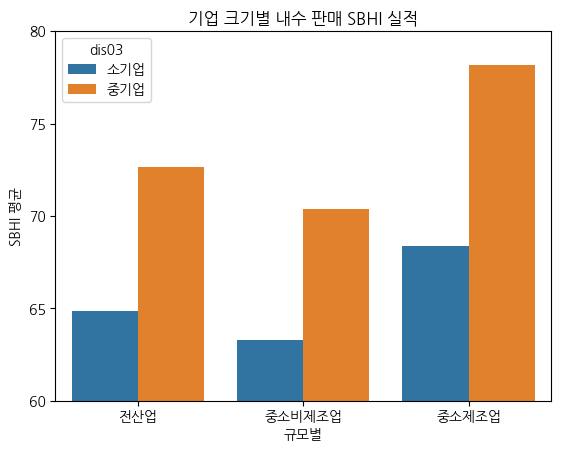

    dis01 dis03  mean_sbhi
0     전산업   소기업  64.866667
1     전산업   중기업  72.633333
2  중소비제조업   소기업  63.283333
3  중소비제조업   중기업  70.383333
4   중소제조업   소기업  68.366667
5   중소제조업   중기업  78.183333


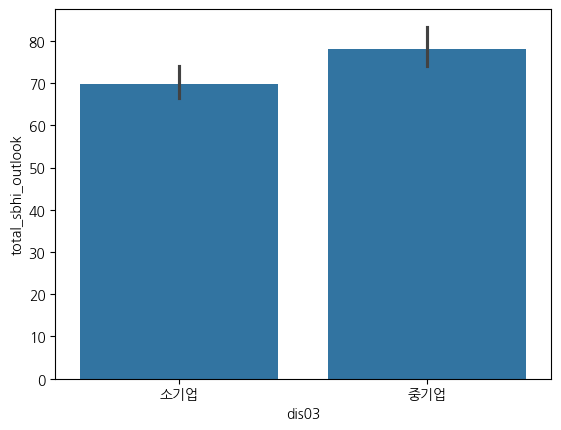

     dis01 dis03  total_sbhi_outlook
2      전산업   소기업           68.928571
3      전산업   중기업           76.771429
9    중소제조업   소기업           74.028571
10   중소제조업   중기업           83.357143
37  중소비제조업   소기업           66.585714
38  중소비제조업   중기업           74.085714


In [20]:
# 전반적인 SBHI 수치 파악 -> 소기업 & 중기업의 SBHI 실적 & 전망 확인

all_domestic_sale_perf = Domestic_sales_performance_SBHI.query('dis02 == "규모별"') \
.groupby(['dis01', 'dis03'], as_index=False) \
.agg(mean_sbhi = ('total_sbhi_pref', 'mean'))

sns.barplot(data=all_domestic_sale_perf, x='dis01', y='mean_sbhi', hue='dis03')
plt.title('기업 크기별 내수 판매 SBHI 실적')
plt.xlabel('규모별')
plt.ylabel('SBHI 평균')
plt.ylim(60, 80)
plt.yticks(np.arange(60, 81, 5))
plt.show()
print(all_domestic_sale_perf)


all_domestic_sale_outlook = Domestic_sales_outlook_SBHI.query('dis02 == "규모별"') \
  [['dis01', 'dis03', 'total_sbhi_outlook']]
sns.barplot(data=all_domestic_sale_outlook, x='dis03', y='total_sbhi_outlook')
plt.show()
print(all_domestic_sale_outlook)

         dis03  total_sbhi_pref
29  자동차 및 트레일러        86.900000
30     기타 운송장비        85.200000
11         식료품        83.466667
50      교육서비스업        83.200000
12          음료        82.783333


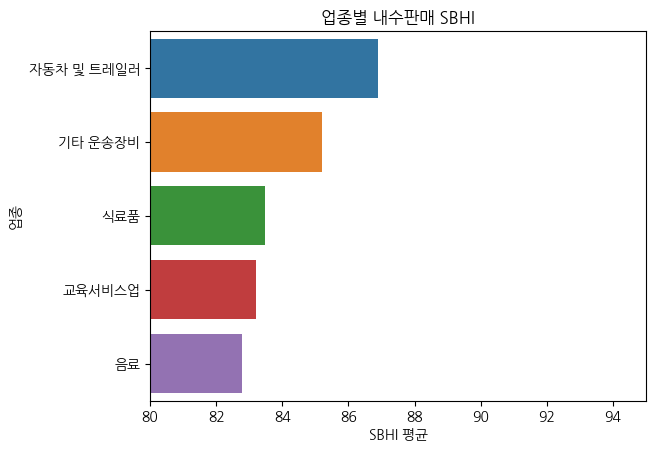

           dis03  total_sbhi_outlook
29    자동차 및 트레일러           90.657143
20  의료용 물질 및 의약품           89.385714
12            음료           87.500000
30       기타 운송장비           87.200000
11           식료품           85.857143


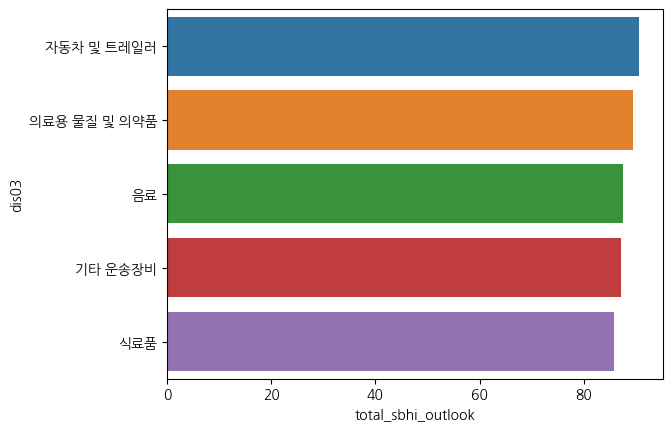

In [21]:
# 실적 / 전망의 SBHI 지수 가장 높은 업종 찾기
top5_domestic_sale_pref = Domestic_sales_performance_SBHI.query('dis02 == "업종별"') \
  [['dis03', 'total_sbhi_pref']] \
  .sort_values('total_sbhi_pref', ascending=False) \
  .head(5)

top5_domestic_sale_outlook = Domestic_sales_outlook_SBHI.query('dis02 == "업종별"') \
  [['dis03', 'total_sbhi_outlook']] \
  .sort_values('total_sbhi_outlook', ascending=False) \
  .head(5)


# 시각화 하기
print(top5_domestic_sale_pref)
sns.barplot(data=top5_domestic_sale_pref, x='total_sbhi_pref', y='dis03', hue='dis03')
plt.title("업종별 내수판매 SBHI")
plt.xlabel("SBHI 평균")
plt.ylabel("업종")
plt.xlim(80, 95)
plt.show()

print(top5_domestic_sale_outlook)
sns.barplot(data=top5_domestic_sale_outlook, x='total_sbhi_outlook', y='dis03', hue='dis03')
plt.show()

### 실적
- 섬유제품        55.450000
- 비금속 광물제품        60.866667
- 목재 및 나무제품        61.283333
- 가구 제조        62.166667
- 건설업        62.700000

### 전망
- 목재 및 나무제품           64.885714
- 가구 제조           65.671429
- 비금속 광물제품           66.142857
- 도매 및 소매업           67.257143
- 건설업           67.328571


             dis03  total_sbhi_pref
13            섬유제품        55.450000
22        비금속 광물제품        60.866667
16       목재 및 나무제품        61.283333
31           가구 제조        62.166667
41             건설업        62.700000
43        도매 및 소매업        63.633333
21     고무제품 및 플라스틱        64.483333
52  수리 및 기타 개인서비스업        66.933333
19     화학물질 및 화학제품        67.650000
42            서비스업        67.750000


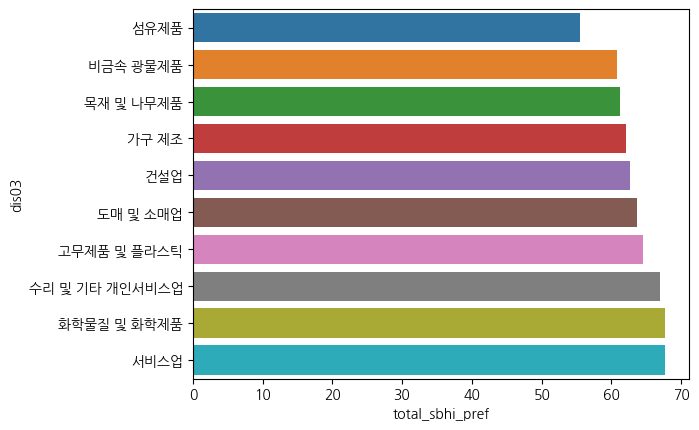

        dis03  total_sbhi_outlook
16  목재 및 나무제품           64.885714
31      가구 제조           65.671429
22   비금속 광물제품           66.142857
43   도매 및 소매업           67.257143
41        건설업           67.328571


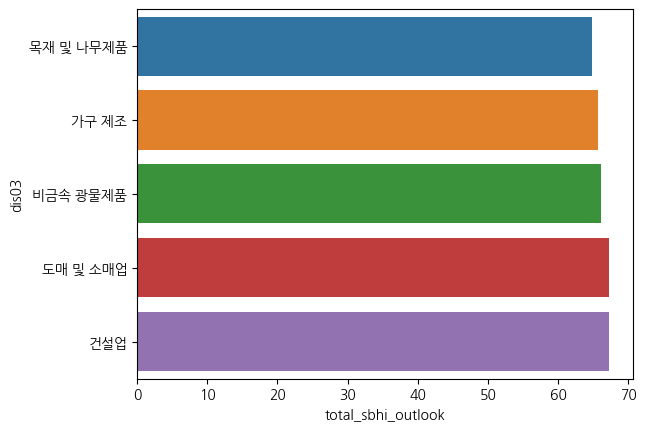

In [22]:
# 실적 / 전망의 SBHI 지수 가장 낮은 업종 찾기
botoom5_domestic_sale_pref = Domestic_sales_performance_SBHI.query('dis02 == "업종별"') \
  [['dis03', 'total_sbhi_pref']] \
  .sort_values('total_sbhi_pref', ascending=True) \
  .head(10)

bottom5_domestic_sale_outlook = Domestic_sales_outlook_SBHI.query('dis02 == "업종별"') \
  [['dis03', 'total_sbhi_outlook']] \
  .sort_values('total_sbhi_outlook', ascending=True) \
  .head(5)


# 시각화 하기
print(botoom5_domestic_sale_pref)
sns.barplot(data=botoom5_domestic_sale_pref, x='total_sbhi_pref', y='dis03', hue='dis03')

plt.show()

print(bottom5_domestic_sale_outlook)
sns.barplot(data=bottom5_domestic_sale_outlook, x='total_sbhi_outlook', y='dis03', hue='dis03')
plt.show()

### 전산업 상위 5개의 애로사항
- 매출(제품 판매) 부진 : 57.255449
- 인건비 상승 :	35.559295
- 원자재(원재료) 상승 :	31.424038
- 업체 간 경쟁 심화 :	24.841987
- 자금조달 곤란 :	16.482692

In [23]:
# 가장 높은 애로사항 확인
enterprise_problems = pd.read_excel('기업경영상_애로요인_복수응답.xlsx')
enterprise_problems.head()

# 1. 가장 높은 애로사항은 무엇인가?
'''
데이터 값들을 순자형으로 변환하기
월별 SBHI 평균 수치 구하기
월별 SBHI 평균 수치 제외한 데이터프레임 생성
해당 column별 평균 중 큰 5개만 출력
'''

# 문자열 -> 실수로 변환
for month in range(1, 7): # 1월부터 6월까지
    for day in range(0, 16):
      if day == 0:
        col_name = f'2025.{month:02d}'
        enterprise_problems[col_name] = pd.to_numeric(enterprise_problems[col_name], errors='coerce')
      else:
        col_name = f'2025.{month:02d}.{day}'
        enterprise_problems[col_name] = pd.to_numeric(enterprise_problems[col_name], errors='coerce')

# 월별 통계량 구하기
# 반복문을 돌며, 1월 ~ 6월까지 더하기
# 다 돌았으면 6으로 나누고 데이터프레임에 저장시키기

mean_enterprise_problems = enterprise_problems.copy()

for day in range(0, 16): # 1월부터 6월까지
    if day == 0:
      mean_enterprise_problems[f'problem_{day}'] = (enterprise_problems['2025.01'] + enterprise_problems['2025.02'] + enterprise_problems['2025.03'] + enterprise_problems['2025.04'] + enterprise_problems['2025.05'] + enterprise_problems['2025.06']) / 6

    else:
      mean_enterprise_problems[f'problem_{day}'] = (enterprise_problems[f'2025.01.{day}'] + enterprise_problems[f'2025.02.{day}'] + enterprise_problems[f'2025.03.{day}'] + enterprise_problems[f'2025.04.{day}'] + enterprise_problems[f'2025.05.{day}'] + enterprise_problems[f'2025.06.{day}']) / 6

# problem만 들어있는 컬럼 만들기.
mean_enterprise_problems = mean_enterprise_problems[[col for col in mean_enterprise_problems.columns if 'problem' in col]]
mean_enterprise_problems.mean().nlargest(5)


# name = enterprise_problems[['구분별(1)', '구분별(2)', '구분별(3)']]

# top5_problem = enterprise_problems.drop(['구분별(1)', '구분별(2)', '구분별(3)'], axis=1, inplace=False) \
# .mean() \
# .nlargest(5) \




# print(top5_problem)

FileNotFoundError: [Errno 2] No such file or directory: '기업경영상_애로요인_복수응답.xlsx'

###매출 부진이 가장 심한 업종
- 15	가죽, 가방 및 신발	73.050000
- 16	목재 및 나무제품	68.183333
- 19	화학물질 및 화학제품	67.266667
- 14	의복 및 모피제품	66.816667
- 22	비금속 광물제품	66.516667

###매출 부진이 가장 심하지 않은 업종
- 30	기타 운송장비	36.133333
- 49	사업시설관리, 사업지원 및 임대서비스업	40.150000
- 20	의료용 물질 및 의약품	40.933333
- 44	운수업	44.066667
- 29	자동차 및 트레일러	44.083333

In [ ]:
# 2. 매출 부진이 가장 심한 산업과 그렇지 않은 산업은 무엇인가?
industry = Domestic_sales_performance['dis03']
mean_enterprise_problems['dis03'] = industry
mean_enterprise_problems.sort_values('problem_4', ascending=False) \
[['dis03', 'problem_4']] \
.head(5)

mean_enterprise_problems.sort_values('problem_4', ascending=True) \
[['dis03', 'problem_4']] \
.head(5)

### 인건비가 가장 많이 상승한 산업
- 48	전문, 과학 및 기술서비스업	56.966667
- 49	사업시설관리, 사업지원 및 임대서비스업	55.983333
- 46	출판,영상,방송통신 및 정보서비스업	55.900000
- 50	교육서비스업	50.366667
- 29	자동차 및 트레일러	47.600000

### 그렇지 않은 산업
- 22	비금속 광물제품	16.983333
- 19	화학물질 및 화학제품	21.716667
- 40	혁신형기업	25.333333
- 16	목재 및 나무제품	25.833333
- 17	펄프 및 종이제품	26.300000

In [ ]:
# 3. 인건비가 가장 많이 상승한 산업과 그렇지 않은 산업은 무엇인가?
mean_enterprise_problems.sort_values('problem_2', ascending=False) \
[['dis03', 'problem_2']] \
.head(5)

mean_enterprise_problems.sort_values('problem_2', ascending=True) \
[['dis03', 'problem_2']] \
.head(5)

#자동차 및 트레일러
1. 인건비 상승
2. 매출 부진
3. 원자재 가격 상승
4. 인력 확보 어려움

# 기타 운송 장비
1. 인건비 상승
2. 원자재 가격 상승
3. 매출 부진
4. 인력 확보 어려움

# 식료품
1. 매출 부진
2. 원자재 가격 상승
3. 인건비 상승
4. 인력 확보 어려움

# 교육서비스업
1. 매출 부진
2. 인건비 상승
3. 업체 간 경쟁 심화
4. 인력확보 어려움

# 음료
1. 매출 부진
2. 원자재 가격 상승
3. 인건비 상승
4. 물류(운송비) 상승


In [ ]:
## 내수판매 SBHI가 가장 높은 산업들의 기업 애로사항

# 자동차 및 트레일러
mean_enterprise_problems.iloc[29].drop('dis03', axis=0, inplace=False) \
.sort_values(ascending=False)

# 기타 운송 장비
mean_enterprise_problems.iloc[30].drop('dis03', axis=0, inplace=False) \
.sort_values(ascending=False)

# 식료품
mean_enterprise_problems.iloc[11].drop('dis03', axis=0, inplace=False) \
.sort_values(ascending=False)

# 교육서비스업
mean_enterprise_problems.iloc[50].drop('dis03', axis=0, inplace=False) \
.sort_values(ascending=False)

# 음료
mean_enterprise_problems.iloc[12].drop('dis03', axis=0, inplace=False) \
.sort_values(ascending=False)

# 수출 데이터 로드

In [ ]:
export_performance = pd.read_excel('수출실적.xlsx')
export_outlook = pd.read_excel('수출전망.xlsx')

# 수출 데이터 전처리

In [ ]:
# 이름 변경
export_performance = export_performance.rename(columns={
    '구분별(1)': 'dis01',
    '구분별(2)': 'dis02',
    '구분별(3)': 'dis03',
    '2025.01.5': '01_SBHI',
    '2025.02.5': '02_SBHI',
    '2025.03.5': '03_SBHI',
    '2025.04.5': '04_SBHI',
    '2025.05.5': '05_SBHI',
    '2025.06.5': '06_SBHI'
})

export_outlook = export_outlook.rename(columns={
    '구분별(1)': 'dis01',
    '구분별(2)': 'dis02',
    '구분별(3)': 'dis03',
    '2025.01.5': '01_SBHI',
    '2025.02.5': '02_SBHI',
    '2025.03.5': '03_SBHI',
    '2025.04.5': '04_SBHI',
    '2025.05.5': '05_SBHI',
    '2025.06.5': '06_SBHI',
    '2025.07.5': '07_SBHI'
})


# 문자열 -> 숫자로 형 변환하기
for col in ['01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI']:
    export_performance[col] = pd.to_numeric(export_performance[col], errors='coerce')

for col in ['01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI', '07_SBHI']:
    export_outlook[col] = pd.to_numeric(export_outlook[col], errors='coerce')

# 필요한 열 추출, 파생 변수 생성
export_performance = export_performance[['dis01','dis02', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI']] \
.assign(total_sbhi_pref = (export_performance['01_SBHI'] + export_performance['02_SBHI'] + export_performance['03_SBHI'] + export_performance['04_SBHI'] + export_performance['05_SBHI'] + export_performance['06_SBHI'])/6)


export_outlook = export_outlook[['dis01','dis02', 'dis03', '01_SBHI', '02_SBHI', '03_SBHI', '04_SBHI', '05_SBHI', '06_SBHI', '07_SBHI']] \
.assign(total_sbhi_outlook = (export_outlook['01_SBHI'] + export_outlook['02_SBHI'] + export_outlook['03_SBHI'] + export_outlook['04_SBHI'] + export_outlook['05_SBHI'] + export_outlook['06_SBHI'] + export_outlook['07_SBHI'])/7)

# 테스트
export_performance.head()
export_outlook.head()

# 1월 ~ 6월/7월 제거
R_export_performance = export_performance[['dis01', 'dis02', 'dis03', 'total_sbhi_pref']]
R_export_outlook = export_outlook[['dis01', 'dis02', 'dis03', 'total_sbhi_outlook']]

# 수출 실적 & 전망이 높은 업종 찾기

In [ ]:
R_export_performance.query('dis02 == "업종별"') \
.sort_values('total_sbhi_pref', ascending=False) \
.head(5)

In [ ]:
R_export_outlook.query('dis02 == "업종별"') \
.sort_values('total_sbhi_outlook', ascending=False) \
.head(5)

# 수출 데이터 프레임에 내수판매 데이터프레임 결합하기

In [ ]:
a = Domestic_sales_performance_SBHI[['dis03', 'total_sbhi_pref']]
export_sales_p = R_export_performance.merge(a, how='left', on='dis03')
export_sales_p.query('dis01 == "전산업"')

